# 断点回归教程

### 美国参议院选举中的在位者优势

一个政党这次赢了选举，会不会让它下次更容易赢？直接比较赢家和输家没有意义，赢的一方本来就更受选民欢迎。Lee (2008) 的办法是只看**险胜和惜败**的选举。得票率 50.1% 和 49.9% 的两场选举，候选人和选区的各方面条件应该差不多，谁赢谁输接近于掷硬币。这就是断点回归（RD）的核心想法。

本教程使用随包自带的美国参议院选举数据，把一个完整的 RD 分析从画图做到稳健性检验。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | RD 识别什么 | 连续性假设，以及估计量为什么是「局部」的 |
| 2 | 数据 | 驱动变量、断点、结果变量 |
| 3 | 先画图 | `sp.rdplot` |
| 4 | 手工做一次局部线性回归 | RD 估计量就是断点两侧两条回归线的截距之差 |
| 5 | `sp.rdrobust` | 最优带宽，常规推断和稳健偏差校正推断 |
| 6 | 带宽敏感性 | 结论是否依赖带宽 |
| 7 | 核函数、多项式阶数、甜甜圈 | 以及为什么不要用全局高阶多项式 |
| 8 | 操纵检验 | 驱动变量的密度在断点处是否连续 |
| 9 | 安慰剂断点 | 在不该有跳跃的地方找跳跃 |
| 10 | 偏差感知的置信区间 | `sp.rd_honest` |
| 11 | 模糊断点 | 处理概率在断点处跳跃但不是从 0 到 1 |
| 12 | 小结 | 一份 RD 分析的清单 |

## 1. RD 识别什么

RD 需要一个**驱动变量** $X$（running variable）和一个**断点** $c$。处理由驱动变量是否越过断点决定。

$$
D_i = \mathbb{1}\{X_i \ge c\}.
$$

这叫**精确断点**（sharp RD）。它识别的是断点处的平均处理效应。

$$
\tau = E\big[Y(1) - Y(0) \mid X = c\big] = \lim_{x \downarrow c} E[Y \mid X = x] - \lim_{x \uparrow c} E[Y \mid X = x].
$$

等式成立靠的是**连续性假设**。两个潜在结果的条件期望 $E[Y(0) \mid X = x]$ 和 $E[Y(1) \mid X = x]$ 在断点处连续。直白地说，如果没有处理，结果变量在越过断点时不会自己跳一下。

这个假设在什么情况下会失效？最常见的是个体能够**精确操纵**自己的驱动变量。假如候选人能把得票率精确地控制在刚过 50%，那么险胜的人和惜败的人就不再可比。第 8 节会检验这一点。

还要注意 $\tau$ 是**局部**的。它只告诉我们断点处的效应，对远离断点的个体没有直接的说明。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 数据

`sp.datasets.lee_2008_senate()` 是 R `rdrobust` 包自带的美国参议院选举数据，由 Cattaneo, Frandsen and Titiunik (2015) 整理，共 1,390 场选举。函数名里的 Lee (2008) 指的是这个研究设计的出处，他的原文用的是众议院数据。

| 变量 | 含义 | 角色 |
| --- | --- | --- |
| `x` | 民主党在本次选举中的得票率差距（百分点）。大于 0 表示民主党获胜 | 驱动变量，断点为 0 |
| `y` | 民主党在该席位下一次选举中的得票率（0 到 100） | 结果变量 |

处理是「民主党赢得本次选举」。有 93 场选举的 `y` 缺失，下面先去掉。

In [2]:
senate = sp.datasets.lee_2008_senate().dropna().reset_index(drop=True)
senate["win"] = (senate["x"] >= 0).astype(int)

print(senate.shape)
print(senate.groupby("win")["y"].agg(["count", "mean"]).round(2))
print(f"\n赢家与输家下次得票率的原始差距: {senate.loc[senate.win == 1, 'y'].mean() - senate.loc[senate.win == 0, 'y'].mean():.1f} 个百分点")

(1297, 3)
     count   mean
win              
0      595  40.92
1      702  62.62

赢家与输家下次得票率的原始差距: 21.7 个百分点


本次获胜的一方，下次得票率平均高出二十多个百分点。这个差距绝大部分不是因果效应，大胜的政党所在的州本来就偏向它。RD 要回答的是，在本次选举势均力敌的那些州里，赢和输本身带来多大差别。

## 3. 先画图

RD 分析的第一步永远是画图。`sp.rdplot` 把驱动变量分成若干小区间，画出每个区间里结果变量的均值，再在断点两侧各拟合一条多项式曲线。相当于 Stata 和 R 里的 `rdplot`。

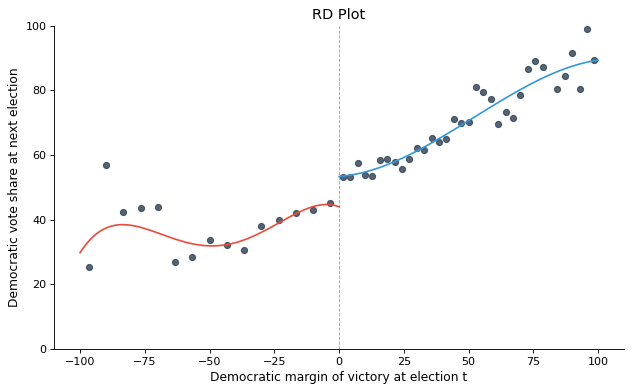

In [3]:
fig, ax = sp.rdplot(
    senate, y="y", x="x", c=0, figsize=(8, 5),
    hide_ci=True,  # 两端的区间样本很少，误差线会把纵轴撑得很大，这里先不画
    x_label="Democratic margin of victory at election t",
    y_label="Democratic vote share at next election",
)
ax.set_ylim(0, 100)
plt.show()

两点值得注意。

- 断点左右的散点整体上沿着一条向上的趋势线分布，在 0 处有一个清楚的向上跳跃。
- 图中的曲线是**全局**四阶多项式，只用来帮助眼睛看趋势。真正的估计不用它，原因见第 7 节。

如果图上看不到跳跃，后面无论回归跑出多显著的结果，都应该保持怀疑。

## 4. 手工做一次局部线性回归

RD 估计量在做的事情很简单。只取断点附近带宽 $h$ 以内的观测，在断点两侧各拟合一条直线，两条直线在断点处的截距之差就是估计值。离断点越近的观测权重越大，权重由核函数给出。最常用的三角核是 $K(u) = 1 - |u|$，其中 $u = (X - c)/h$。

写成一个回归就是

$$
Y_i = \alpha + \tau D_i + \beta_1 (X_i - c) + \beta_2 D_i (X_i - c) + \varepsilon_i, \qquad |X_i - c| < h,
$$

按核权重做加权最小二乘，$\hat\tau$ 就是 RD 估计值。下面先借用 `sp.rdrobust` 选出的带宽，手工跑一遍。

In [4]:
h = sp.rdrobust(senate, y="y", x="x", c=0).model_info["bandwidth_h"]

local = senate[senate["x"].abs() < h].copy()
local["kernel_w"] = 1 - local["x"].abs() / h      # 三角核权重

manual = sp.regress("y ~ win + x + win:x", data=local, weights="kernel_w")
print(f"带宽 h = {h:.2f}，带宽内的观测数 = {len(local)}")
print(f"手工局部线性回归: win 系数 = {manual.params['win']:.4f}")

带宽 h = 17.75，带宽内的观测数 = 683
手工局部线性回归: win 系数 = 7.4141


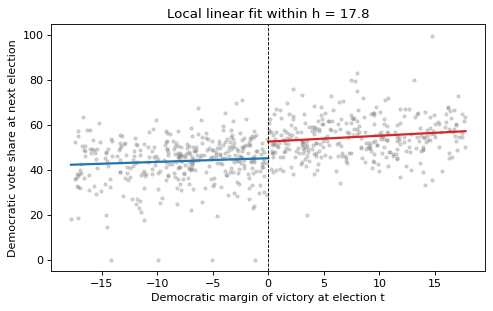

In [5]:
# 把这两条局部回归线画出来
grid_l, grid_r = np.linspace(-h, 0, 50), np.linspace(0, h, 50)
b = manual.params

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(local["x"], local["y"], s=8, alpha=0.3, color="grey")
ax.plot(grid_l, b["Intercept"] + b["x"] * grid_l, color="C0", lw=2)
ax.plot(grid_r, b["Intercept"] + b["win"] + (b["x"] + b["win:x"]) * grid_r, color="C3", lw=2)
ax.axvline(0, color="black", ls="--", lw=0.8)
ax.set_xlabel("Democratic margin of victory at election t")
ax.set_ylabel("Democratic vote share at next election")
ax.set_title(f"Local linear fit within h = {h:.1f}")
plt.show()

## 5. `sp.rdrobust`

`sp.rdrobust` 实现了 Calonico, Cattaneo and Titiunik (2014) 的估计和推断方法，与 Stata 和 R 的 `rdrobust` 命令对应。默认设定是局部线性回归、三角核、均方误差最优带宽。

In [6]:
rd = sp.rdrobust(senate, y="y", x="x", c=0)
print(rd.summary())

  Sharp RD Estimation

  RD Effect:       7.51 ***
  Std. Error:  (1.74)
  [95% CI]:    [4.09,  10.92]
  P-value:     <0.001

------------------------------------------------------------------------------
  Inference
------------------------------------------------------------------------------
      method  estimate     se      z  pvalue  ci_lower  ci_upper
Conventional    7.4141 1.4587 5.0826  0.0000    4.5551   10.2732
      Robust    7.5065 1.7413 4.3110  0.0000    4.0937   10.9193

------------------------------------------------------------------------------
  Observations:    1,297
  Rd Type:    Sharp
  Deriv:    0
  Donut:    0
  Polynomial P:    1
  Polynomial Q:    2
  Kernel:    triangular
  Bandwidth H:    17.7544
  Bandwidth B:    28.0281
  Bwselect:    mserd
  Cutoff:    0
  N Left:    595
  N Right:    702
  N Effective Left:    360
  N Effective Right:    323
  Scalepar:    1
  N Unique Running:    1260
  Vce:    nn
  Weighted:    False
  (2 solver/diagnostic entries hi

这张表里有几处需要解释。

**两行估计**。`Conventional` 一行的 7.41 就是上一节手工算出来的数。`Robust` 一行是偏差校正后的估计和稳健标准误。

**为什么需要偏差校正**。均方误差最优带宽在偏差和方差之间取平衡，这样选出来的带宽下，局部线性估计量的偏差不能忽略，常规置信区间的覆盖率会低于名义水平。Calonico, Cattaneo and Titiunik (2014) 的做法是用一个更高阶的局部多项式估计出偏差并减掉，同时在标准误里计入估计偏差带来的额外不确定性。**汇报推断结果时应该用 `Robust` 这一行**。表头的效应值、标准误和置信区间也来自这一行。

**两个带宽**。`Bandwidth H` 是估计用的主带宽，约 17.8 个百分点。`Bandwidth B` 是估计偏差用的带宽，更宽一些。

**有效样本量**。1,297 场选举里，落在带宽内的只有 683 场（左 360，右 323）。RD 只用断点附近的数据，这是它可信的原因，也是它精度有限的原因。

结论是，民主党险胜一场参议院选举，使它在该席位下一次选举中的得票率提高约 7.5 个百分点，95% 稳健置信区间为 [4.1, 10.9]。

In [7]:
# 结果对象的常用属性
print("点估计      :", round(rd.estimate, 4))
print("稳健标准误  :", round(rd.se, 4))
print("95% 置信区间:", tuple(round(float(v), 4) for v in rd.ci))
rd.detail.round(4)

点估计      : 7.5065
稳健标准误  : 1.7413
95% 置信区间: (4.0937, 10.9193)


,method,estimate,se,z,pvalue,ci_lower,ci_upper
0,Conventional,7.4141,1.4587,5.0826,0.0,4.5551,10.2732
1,Robust,7.5065,1.7413,4.3110,0.0,4.0937,10.9193


## 6. 带宽敏感性

带宽是 RD 里最重要的调节参数。带宽小，偏差小而方差大。带宽大则相反。数据驱动的最优带宽是一个合理的起点，但读者有权知道换一个带宽结论会不会变。

`sp.rdbwselect(all=True)` 列出各种带宽选择方法的结果。`mserd` 是默认的均方误差最优带宽，`cerrd` 是为置信区间覆盖率优化的带宽，通常更窄。

In [8]:
sp.rdbwselect(senate, y="y", x="x", c=0, all=True).round(2)

,method,h_left,h_right,b_left,b_right,n_left,n_right
0,mserd,17.75,17.75,28.03,28.03,360,323
1,msetwo,16.17,18.13,27.10,29.34,336,326
2,msesum,18.37,18.37,31.32,31.32,374,330
3,msecomb1,17.75,17.75,28.03,28.03,360,323
4,msecomb2,17.75,18.13,28.03,29.34,360,326
5,cerrd,12.41,12.41,28.03,28.03,284,248
6,certwo,11.30,12.67,27.10,29.34,266,252
7,cersum,12.83,12.83,31.32,31.32,290,255
8,cercomb1,12.41,12.41,28.03,28.03,284,248
9,cercomb2,12.41,12.67,28.03,29.34,284,252


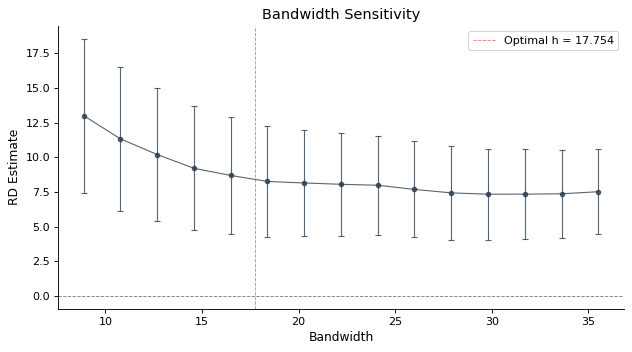

,bandwidth,estimate,se,ci_lower,ci_upper,pvalue
0,8.877,12.995,2.836,7.437,18.553,0.0
1,10.779,11.322,2.639,6.150,16.494,0.0
2,12.682,10.190,2.440,5.407,14.972,0.0
3,14.584,9.199,2.274,4.742,13.656,0.0
4,16.486,8.683,2.149,4.471,12.895,0.0
5,18.388,8.251,2.030,4.272,12.229,0.0
6,20.291,8.140,1.947,4.324,11.957,0.0
7,22.193,8.046,1.890,4.342,11.750,0.0
8,24.095,7.976,1.826,4.397,11.556,0.0
9,25.998,7.677,1.768,4.212,11.143,0.0


In [9]:
# 在一系列带宽下重新估计。默认范围是最优带宽的 0.5 到 2 倍
bw_sens = sp.rdbwsensitivity(senate, y="y", x="x", c=0, figsize=(8, 4.5))
plt.show()
bw_sens.round(3)

所有带宽下估计值都显著为正，方向没有疑问。但效应的**大小**对带宽是敏感的。带宽从 9 增加到 35，估计值从 13 降到 7.5 左右。窄带宽下的估计更大，同时标准误也更大。

这种模式在实际数据里很常见，如实汇报就好。可以在正文里报告最优带宽下的结果，把这张图放进附录，并指出各个带宽下的点估计都不低于 7 个百分点。

## 7. 核函数、多项式阶数、甜甜圈

除了带宽，还有几个设定值得检查。

- **核函数**。三角核在理论上对边界点估计最优，`epanechnikov` 和 `uniform` 是常见的替代。
- **多项式阶数**。`p=1` 是局部线性，`p=2` 是局部二次。
- **甜甜圈**（donut）。去掉紧挨断点的观测再估计。如果担心断点附近存在操纵或数据堆积，这个检验很有用。

In [10]:
specs = {
    "baseline (triangular, p=1)": {},
    "epanechnikov kernel": {"kernel": "epanechnikov"},
    "uniform kernel": {"kernel": "uniform"},
    "local quadratic (p=2)": {"p": 2},
    "donut: drop |x| < 1": {"donut": 1},
}
rows = []
for label, kwargs in specs.items():
    r = sp.rdrobust(senate, y="y", x="x", c=0, **kwargs)
    rows.append((label, r.estimate, r.se, r.ci[0], r.ci[1], r.model_info["bandwidth_h"]))

pd.DataFrame(rows, columns=["specification", "estimate", "robust_se", "ci_lower", "ci_upper", "h"]).round(3)

,specification,estimate,robust_se,ci_lower,ci_upper,h
0,"baseline (triangular, p=1)",7.507,1.741,4.094,10.919,17.754
1,epanechnikov kernel,7.300,1.768,3.835,10.766,16.104
2,uniform kernel,7.593,1.852,3.963,11.224,11.597
3,local quadratic (p=2),8.317,2.093,4.214,12.419,22.256
4,donut: drop |x| < 1,6.395,2.147,2.187,10.604,18.354


五种设定给出的估计值在 6.4 到 8.3 之间，置信区间都不含 0。

### 为什么不用全局高阶多项式

早期文献常用全样本拟合一个高阶多项式，再读断点处的跳跃。Gelman and Imbens (2019) 明确反对这种做法。高阶多项式会给远离断点的观测很大的、甚至为负的隐含权重，估计值对阶数很敏感，置信区间的覆盖率也不可靠。

下面用全样本跑一到六阶多项式，看估计值怎么变。

In [11]:
rows = []
for order in range(1, 7):
    poly = " + ".join(f"I(x**{k}) + win:I(x**{k})" for k in range(1, order + 1))
    fit = sp.regress(f"y ~ win + {poly}", data=senate, robust="hc1")
    rows.append((order, fit.params["win"], fit.std_errors["win"]))

pd.DataFrame(rows, columns=["global polynomial order", "estimate", "se"]).round(3)

,global polynomial order,estimate,se
0,1,6.044,0.894
1,2,4.935,1.129
2,3,7.319,1.402
3,4,9.407,1.659
4,5,7.958,1.969
5,6,6.627,2.291


估计值随阶数来回变动，而你没有什么原则性的理由选其中某一个。局部线性回归加数据驱动的带宽把这个选择交给了一个有理论依据的规则。

## 8. 操纵检验

如果个体能够精确操纵驱动变量，断点一侧会出现异常多的观测，驱动变量的密度在断点处就不连续。McCrary (2008) 最早提出检验这一点。`sp.rddensity` 实现的是 Cattaneo, Jansson and Ma (2020) 的局部多项式密度检验，对应 Stata 和 R 的 `rddensity`。

原假设是密度在断点处连续。**我们希望不拒绝**。

In [12]:
dens = sp.rddensity(sp.datasets.lee_2008_senate(), x="x", c=0)
print(f"断点左侧密度估计: {dens.model_info['density_left']:.5f}")
print(f"断点右侧密度估计: {dens.model_info['density_right']:.5f}")
print(f"检验统计量 T = {dens.estimate:.3f},  p = {dens.pvalue:.3f}")

断点左侧密度估计: 0.02169
断点右侧密度估计: 0.01814
检验统计量 T = -0.875,  p = 0.381


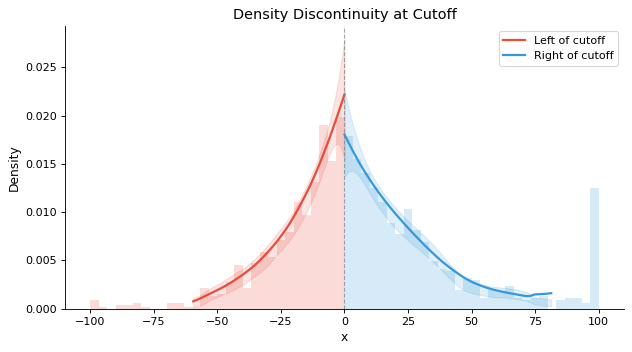

In [13]:
fig, ax = sp.rdplotdensity(sp.datasets.lee_2008_senate(), x="x", c=0, figsize=(8, 4.5))
plt.show()

p 值为 0.38，没有证据表明得票率差距在 0 附近被操纵。这符合直觉，全州范围的选举结果很难被精确控制在刚过半数。

密度检验用的是全部 1,390 场选举，包括 `y` 缺失的那些，因为它只需要驱动变量。

如果数据里有处理前就已确定的协变量（比如上一届的得票率、州的人口特征），还应该把它们当作结果变量各跑一次 RD，确认它们在断点处没有跳跃。`sp.rdbalance` 做的就是这件事。这份数据只有两列，第 11 节会在模拟数据上演示。

## 9. 安慰剂断点

真正的断点在 0。在其他位置，没有任何处理发生变化，结果变量不应该跳。`sp.rdplacebo` 在一组假想的断点上重复 RD 估计。为了不让真实的跳跃污染结果，断点左侧的安慰剂检验只用左侧的数据，右侧同理。

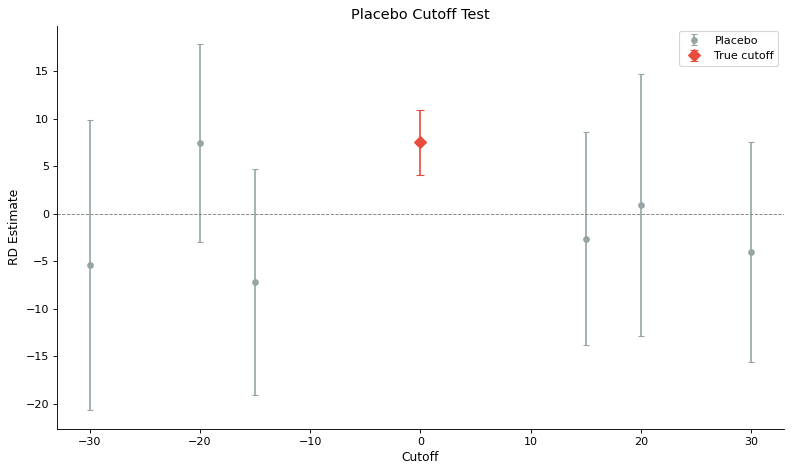

,cutoff,estimate,se,ci_lower,ci_upper,pvalue,is_true_cutoff
0,-30,-5.429,7.787,-20.692,9.834,0.486,False
1,-20,7.414,5.322,-3.017,17.845,0.164,False
2,-15,-7.226,6.064,-19.112,4.660,0.233,False
3,0,7.507,1.741,4.094,10.919,0.000,True
4,15,-2.621,5.735,-13.861,8.620,0.648,False
5,20,0.937,7.033,-12.847,14.721,0.894,False
6,30,-4.010,5.892,-15.559,7.538,0.496,False


In [14]:
placebo = sp.rdplacebo(senate, y="y", x="x", c=0, placebo_cutoffs=[-30, -20, -15, 15, 20, 30])
plt.show()
placebo.round(3)

只有真实断点处的估计显著。六个假想断点的估计值都不显著，置信区间都包含 0。

做这类检验时要记住两件事。安慰剂断点的位置要**事先**定好，不能挑着报。检验的个数多了，偶尔出现一个 p < 0.05 也是正常的。

## 10. 偏差感知的置信区间

稳健偏差校正是处理偏差的一种方式。Armstrong and Kolesár (2020) 给出了另一种。先对条件期望函数的弯曲程度设一个上界 $M$（二阶导数的绝对值不超过 $M$），然后在这个函数类里计算估计量的最坏偏差，把它直接加进置信区间。这样得到的区间在整个函数类上都有正确的覆盖率，所以叫 honest。

`sp.rd_honest` 默认用数据估计一个 $M$，也可以由研究者指定。

In [15]:
honest = sp.rd_honest(senate, y="y", x="x", c=0)
mi = honest.model_info

print(f"点估计            : {honest.estimate:.3f}")
print(f"平滑度上界 M      : {mi['M']:.4f}  (由数据估计)")
print(f"最坏偏差          : {mi['bias_bound']:.3f}")
print(f"带宽              : {mi['bandwidth']:.2f}")
print(f"honest 95% 置信区间: [{honest.ci[0]:.2f}, {honest.ci[1]:.2f}]")

点估计            : 8.030
平滑度上界 M      : 0.1135  (由数据估计)
最坏偏差          : 1.129
带宽              : 9.84
honest 95% 置信区间: [3.82, 12.24]


这个方法在它自己的最优带宽（约 9.8）下给出 8.0 的点估计，95% 置信区间为 [3.8, 12.2]，与稳健偏差校正的 [4.1, 10.9] 很接近。两种思路不同的方法给出一致的结论，这本身就是一种稳健性证据。

## 11. 模糊断点

很多应用里，越过断点并不保证接受处理，只是使接受处理的**概率**跳了一下。例如分数过线的学生获得奖学金资格，但不是每个人都接受。这是**模糊断点**（fuzzy RD）。

模糊断点的估计量是两个跳跃之比。

$$
\tau_{fuzzy} = \frac{\text{结果变量在断点处的跳跃}}{\text{处理概率在断点处的跳跃}}.
$$

它和工具变量是一回事。「是否越过断点」是工具变量，它识别的是断点处依从者的平均效应。

真实的选举数据是精确断点，所以这一节换成模拟数据。真实处理效应设为 2，越过断点使处理概率从 0.2 跳到 0.8。另外加入一个与处理无关的协变量 `age`，用来演示协变量平衡检验。

In [16]:
rng = np.random.default_rng(7)
n = 4000

score = rng.uniform(-1, 1, n)                                   # 驱动变量，断点为 0
age = rng.normal(40, 10, n)                                     # 处理前协变量
treated = rng.binomial(1, np.where(score >= 0, 0.8, 0.2))       # 处理概率在断点处从 0.2 跳到 0.8
outcome = 1 + 0.8 * score + 0.3 * score**2 + 2.0 * treated + 0.01 * age + rng.normal(0, 1, n)

fuzzy_df = pd.DataFrame({"score": score, "treated": treated, "outcome": outcome, "age": age})

# 分别估计两个跳跃
jump_y = sp.rdrobust(fuzzy_df, y="outcome", x="score", c=0)
jump_d = sp.rdrobust(fuzzy_df, y="treated", x="score", c=0)
print(f"结果变量的跳跃 : {jump_y.estimate:.3f}")
print(f"处理概率的跳跃 : {jump_d.estimate:.3f}")
print(f"两者之比       : {jump_y.estimate / jump_d.estimate:.3f}   (真实效应 = 2)")

结果变量的跳跃 : 1.301
处理概率的跳跃 : 0.589
两者之比       : 2.208   (真实效应 = 2)


In [17]:
# 一步到位。fuzzy= 指定实际接受处理的变量
frd = sp.rdrobust(fuzzy_df, y="outcome", x="score", c=0, fuzzy="treated")
print(frd.summary())

  Fuzzy RD Estimation

  LATE:       2.178 ***
  Std. Error:  (0.287)
  [95% CI]:    [1.615,  2.741]
  P-value:     <0.001

------------------------------------------------------------------------------
  Inference
------------------------------------------------------------------------------
      method  estimate     se      z  pvalue  ci_lower  ci_upper
Conventional    2.1721 0.2442 8.8961  0.0000    1.6936    2.6507
      Robust    2.1780 0.2871 7.5865  0.0000    1.6153    2.7407

------------------------------------------------------------------------------
  Observations:    4,000
  Rd Type:    Fuzzy
  Deriv:    0
  Donut:    0
  Polynomial P:    1
  Polynomial Q:    2
  Kernel:    triangular
  Bandwidth H:    0.262624
  Bandwidth B:    0.41901
  Bwselect:    mserd
  Cutoff:    0
  N Left:    2013
  N Right:    1987
  N Effective Left:    534
  N Effective Right:    505
  Scalepar:    1
  First Stage F:    127.934
  N Unique Running:    4000
  Vce:    nn
  Weighted:    False
  (2

模糊断点的估计值约为 2.2，置信区间包含真值 2。手工相除的比值与它略有出入，因为两次单独的估计各自选了带宽，而 `fuzzy=` 在同一个带宽下联合估计，并且给出了正确的标准误。

结果里还报告了第一阶段的 F 统计量。处理概率的跳跃如果很小，模糊断点就会遇到弱工具变量问题。

最后看协变量平衡。`age` 在断点处不应该有跳跃。

In [18]:
sp.rdbalance(fuzzy_df, x="score", c=0, covs=["age"]).round(3)

,covariate,estimate,se,z,pvalue,significant
0,age,0.803,1.42,0.566,0.572,False


## 12. 小结

一份完整的 RD 分析通常包括下面这些内容。

1. **画图**（`sp.rdplot`）。跳跃应该肉眼可见。
2. **主估计**（`sp.rdrobust`）。局部线性、三角核、数据驱动带宽，汇报稳健偏差校正的置信区间。
3. **带宽敏感性**（`sp.rdbwselect`、`sp.rdbwsensitivity`）。
4. **设定敏感性**。核函数、多项式阶数、甜甜圈。不用全局高阶多项式。
5. **操纵检验**（`sp.rddensity`、`sp.rdplotdensity`）。
6. **协变量平衡**（`sp.rdbalance`）。处理前变量在断点处不应跳跃。
7. **安慰剂断点**（`sp.rdplacebo`）。
8. **偏差感知的区间**（`sp.rd_honest`）作为复核。
9. **说明结论的局部性**。估计的是断点处的效应。模糊断点下是断点处依从者的效应。

延伸阅读见 `docs/guides/choosing_rd_estimator.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [19]:
keys = [
    "lee2008randomized",
    "cattaneo2015randomization",
    "calonico2014robust",
    "gelman2019why",
    "mccrary2008manipulation",
    "cattaneo2020simple",
    "armstrong2020simple",
]
print(sp.bibtex(keys))

@article{lee2008randomized,
  title={Randomized Experiments from Non-Random Selection in {U.S.} House Elections},
  author={Lee, David S.},
  journal={Journal of Econometrics},
  volume={142},
  number={2},
  pages={675--697},
  year={2008},
  doi={10.1016/j.jeconom.2007.05.004}
}

@article{cattaneo2015randomization,
  title={Randomization Inference in the Regression Discontinuity Design: An Application to Party Advantages in the U.S. Senate},
  author={Cattaneo, Matias D. and Frandsen, Brigham R. and Titiunik, Roc{\'i}o},
  journal={Journal of Causal Inference},
  volume={3},
  number={1},
  pages={1--24},
  year={2015},
  publisher={De Gruyter},
  doi={10.1515/jci-2013-0010}
}

@article{calonico2014robust,
  title={Robust Nonparametric Confidence Intervals for Regression-Discontinuity Designs},
  author={Calonico, Sebastian and Cattaneo, Matias D. and Titiunik, Roc{\'\i}o},
  journal={Econometrica},
  volume={82},
  number={6},
  pages={2295--2326},
  year={2014},
  publisher={Wiley}